# Praktikum Kecerdasan Buatan
## Materi 2 - Logika Fuzzy



---
**Program Studi** : Informatika  
**Dosen Pengampu** :  
**Nama Mahasiswa** :  
**NIM** :  
**Tanggal Praktikum** :

---
## **Pengantar**
* Apakah semua keputusan di dunia nyata bersifat benar atau salah (biner)?
* Bagaimana cara sistem menangani konsep seperti "cukup panas" atau "agak cepat"?
* Jika sebuah nilai berada di antara dua kategori, bagaimana cara menentukan kategorinya?
* Bagaimana komputer dapat mengambil keputusan dari kondisi yang tidak pasti?

Tuliskan jawaban awal Anda pada cell di bawah ini!

**Jawaban :**

---
## **Tujuan**

Setelah mengikuti praktikum ini, mahasiswa mampu:

* Memahami konsep dasar Logika Fuzzy
* Memahami himpunan fuzzy dan fungsi keanggotaan
* Mengimplementasikan sistem fuzzy menggunakan Python dan SciKit-Fuzzy
* Membangun sistem inferensi fuzzy sederhana
---

## **Dasar Teori**


### **1. Logika Fuzzy**
* Logika Fuzzy adalah pengembangan dari Logika Klasik atau Logika Boolean yang
digunakan untuk menangani konsep kebenaran yang lebih fleksibel.
* Logika Fuzzy didasarkan pada gagasan bahwa kebenaran sesuatu bukan hanya antara benar atau salah, tetapi bisa sebagian benar dan sebagian salah
*  Nilai Kebenaran Logika Fuzzy tidak hanya 0 atau 1, tetapi berada pada rentang [0,1].

Contoh:
* Suhu 25°C → bisa termasuk Hangat (0.7) dan Panas (0.3)

### **2. Himpunan Fuzzy**
* Himpunan Fuzzy adalah sebuah himpunan yang memuat elemen-elemen dengan derajat keanggotaan.
* Himpunan Fuzzy berbeda dengan himpunan klasik yang suatu elemen secara tegas termasuk atau tidak termasuk
* Suatu elemen pada himpunan Fuzzy dapat sebagian besar termasuk di himpunan A, dan sebagian kecil termasuk di himpunan B.
* Seberapa besar bagian dari suatu elemen yang masuk pada masing-masing himpunan tersebut adalah derajat keanggotaannya.
* Derajat keanggotaan pada himpunan Fuzzy memiliki rentang 0 hingga 1

Sebagai contoh, variable suhu dapat dibagi menjadi tiga himpunan Fuzzy, yaitu:
* Himpunan DINGIN : untuk suhu 0°C hingga 20°C
* Himpunan HANGAT : untuk suhu 15°C hingga 35°C
* Himpunan PANAS : untuk suhu 30°C hingga 50°C

### **3. Fungsi Keanggotaan**
* Fungsi keanggotaan adalah sebuah kurva yang menentukan nilai derajat keanggotaan suatu elemen pada suatu himpunan Fuzzy.

Berikut adalah beberapa contoh fungsi

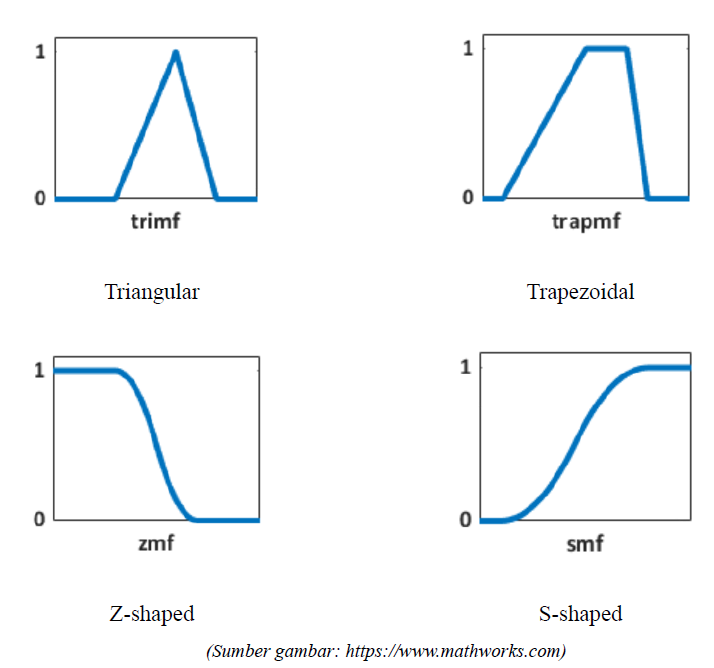

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 45.9 MB/s eta 0:00:00


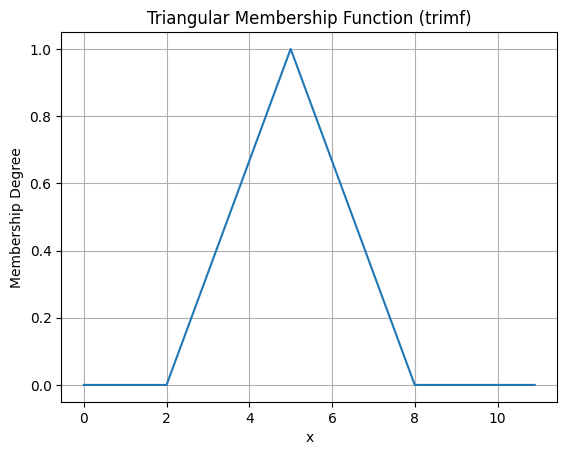

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x = np.arange(0, 11, 0.1)

triangular = fuzz.trimf(x, [2, 5, 8])

plt.plot(x, triangular)
plt.title("Triangular Membership Function (trimf)")
plt.xlabel("x")
plt.ylabel("Membership Degree")
plt.grid()
plt.show()

**Uji Coba**
1. Cobalah ubah fungsi keanggotaan bentuk segitiga ke bentuk lainnya
2. Simpulkan pengaruh bentuk fungsi keanggotaan dengan derajat keanggotaan


**Jawaban :**


---

### **4. Operator Dasar Fuzzy**
* Operator dasar pada Logika Fuzzy digunakan untuk memodifikasi atau membandingkan nilai keanggotaan himpunan Fuzzy.
* Operator-operator yang digunakan mirip dengan operator dasar pada Logika Klasik, yaitu
  * AND
  * OR
  * NOT

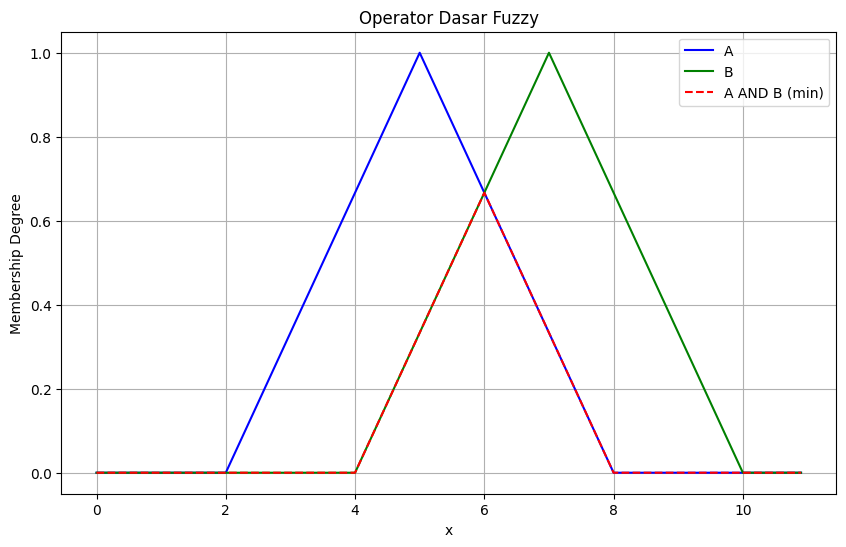

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x = np.arange(0, 11, 0.1)

A = fuzz.trimf(x, [2, 5, 8])
B = fuzz.trimf(x, [4, 7, 10])

AND = np.fmin(A, B)

plt.figure(figsize=(10,6))

plt.plot(x, A, 'b', label='A')
plt.plot(x, B, 'g', label='B')

plt.plot(x, AND, 'r--', label='A AND B (min)')

plt.title("Operator Dasar Fuzzy")
plt.xlabel("x")
plt.ylabel("Membership Degree")
plt.legend()
plt.grid()

plt.show()

**Uji Coba**
1. Cobalah ubah operator AND ke operator lainnya
2. Simpulkan pengaruh operator fuzzy dengan grafik yang dihasilkan


**Jawaban :**


---

### **5. Aturan Fuzzy**
* Aturan Fuzzy adalah pemetaan sederhana yang menggambarkan relasi antara himpunan Fuzzy dalam sebuah statement IF-THEN.
* Bagian IF disebut dengan Antecedent, sedangkan bagian THEN disebut dengan Consequent

Contoh

Bentuk:

`IF kondisi THEN hasil`

Contoh:

`IF makanan enak AND pelayanan ramah THEN nilai baik`

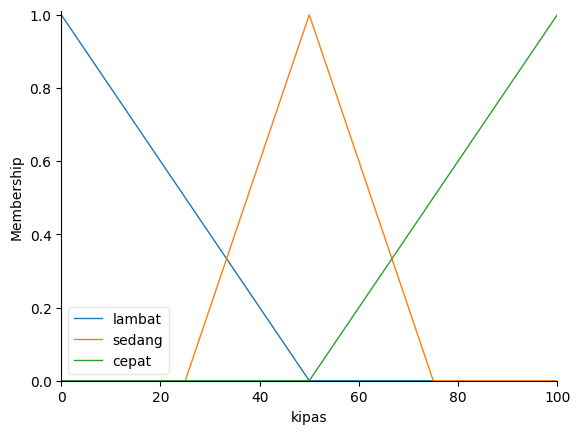

In [ ]:
kipas.view()

In [ ]:
"""
Penilaian Kualitas AC berdasarkan Suhu

Input:
Suhu (°C): Dingin, Normal, Panas
Output:
Kecepatan Kipas: Lambat, Sedang, Cepat
"""

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

suhu = ctrl.Antecedent(np.arange(0, 41, 1), 'suhu')
kipas = ctrl.Consequent(np.arange(0, 101, 1), 'kipas')

# Suhu
suhu['dingin'] = fuzz.trimf(suhu.universe, [0, 0, 20])
suhu['normal'] = fuzz.trimf(suhu.universe, [15, 25, 35])
suhu['panas']  = fuzz.trimf(suhu.universe, [30, 40, 40])

# Kipas
kipas['lambat'] = fuzz.trimf(kipas.universe, [0, 0, 50])
kipas['sedang'] = fuzz.trimf(kipas.universe, [25, 50, 75])
kipas['cepat']  = fuzz.trimf(kipas.universe, [50, 100, 100])

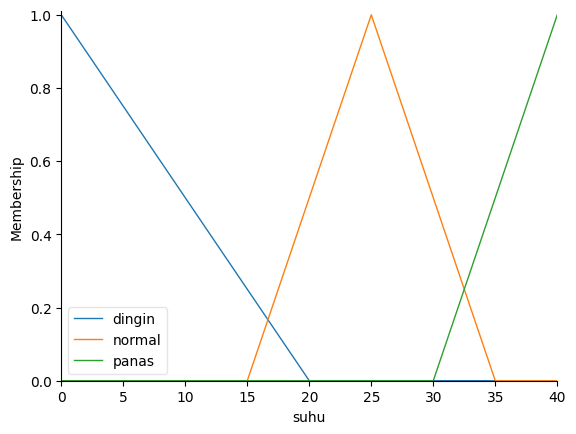

In [ ]:
suhu.view()

In [ ]:
rule1 = ctrl.Rule(suhu['dingin'], kipas['lambat'])
rule2 = ctrl.Rule(suhu['normal'], kipas['sedang'])
rule3 = ctrl.Rule(suhu['panas'], kipas['cepat'])

**Uji Coba**
1. Cobalah terjemahkan apa maksud kode diatas


**Jawaban :**


---

### **6. Inferensi Fuzzy**
* Inferensi Fuzzy adalah proses pengambilan keputusan pada sebuah sistem Fuzzy yang terdiri dari beberapa tahap, yaitu:
  * Fuzzification : mengubah input dengan nilai pasti atau tegas menjadi nilai Fuzzy menggunakan fungsi keanggotaan yang telah ditentukan.
  * Rule Application : menerapkan aturan-aturan Fuzzy yang sudah ditentukan untuk mengevaluasi input Fuzzy dan menghasilkan output Fuzzy sementara.
  * Aggregation : menggabungkan masing-masing output Fuzzy sementara dari setiap penerapan aturan untuk membentuk output Fuzzy yang mencakup keseluruhan sistem.
  * Defuzzification : mengubah kembali nilai Fuzzy menjadi nilai pasti.

In [ ]:
"""
Input: Suhu
Output: Kecepatan Kipas
"""

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

suhu = ctrl.Antecedent(np.arange(0, 41, 1), 'suhu')
kipas = ctrl.Consequent(np.arange(0, 101, 1), 'kipas')

# Suhu
suhu['dingin'] = fuzz.trimf(suhu.universe, [0, 0, 20])
suhu['normal'] = fuzz.trimf(suhu.universe, [15, 25, 35])
suhu['panas']  = fuzz.trimf(suhu.universe, [30, 40, 40])

# Kipas
kipas['lambat'] = fuzz.trimf(kipas.universe, [0, 0, 50])
kipas['sedang'] = fuzz.trimf(kipas.universe, [25, 50, 75])
kipas['cepat']  = fuzz.trimf(kipas.universe, [50, 100, 100])

kipas.defuzzify_method = 'centroid'

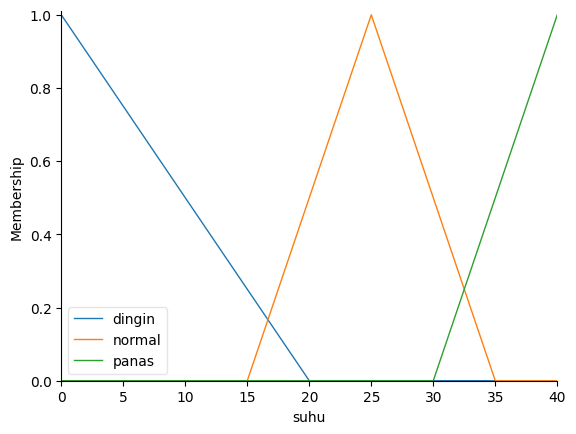

In [ ]:
suhu.view()

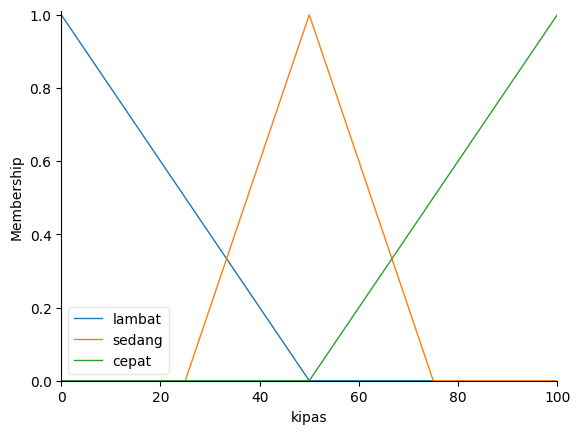

In [ ]:
kipas.view()

  **Fuzzification**
  
  Mengubah input dengan nilai pasti atau tegas menjadi nilai Fuzzy menggunakan fungsi keanggotaan yang telah ditentukan.

In [ ]:
# Fuzzyfication

input_suhu = 40

mu_dingin = fuzz.interp_membership(suhu.universe, suhu['dingin'].mf, input_suhu)
mu_normal = fuzz.interp_membership(suhu.universe, suhu['normal'].mf, input_suhu)
mu_panas  = fuzz.interp_membership(suhu.universe, suhu['panas'].mf, input_suhu)

print("Dingin:", mu_dingin)
print("Normal:", mu_normal)
print("Panas :", mu_panas)

Dingin: 0.0
Normal: 0.0
Panas : 1.0


  **Rule Application**
  
  Menerapkan aturan-aturan Fuzzy yang sudah ditentukan untuk mengevaluasi input Fuzzy dan menghasilkan output Fuzzy sementara.

In [ ]:
# Rule Aplication

rule1 = ctrl.Rule(suhu['dingin'], kipas['lambat'])
rule2 = ctrl.Rule(suhu['normal'], kipas['sedang'])
rule3 = ctrl.Rule(suhu['panas'], kipas['cepat'])

  **Aggregation**
  
  Menggabungkan masing-masing output Fuzzy sementara dari setiap penerapan aturan untuk membentuk output Fuzzy yang mencakup keseluruhan sistem.

In [ ]:
#Aggregation
# aggregated = np.fmax(rule1, np.fmax(rule2, rule3))

engine = ctrl.ControlSystem([rule1, rule2, rule3])
system = ctrl.ControlSystemSimulation(engine)

  **Defuzzification**
  
  Mengubah kembali nilai Fuzzy menjadi nilai pasti.

In [ ]:

#Defuzzyfication

system.input['suhu'] = input_suhu
system.compute()

print("Kecepatan kipas:", system.output['kipas'])

Kecepatan kipas: 83.33333333333336


**Uji Coba**
1. Cobalah Ubah input suhu, Apa yang terjadi ?
2. Coba ubah rule, Apa yang terjadi ?
   * IF panas → sedang (bukan cepat)
3. Coba ganti metode defuzzyfikasi, Apa yang terjadi ?


**Jawaban :**


---

### **7. SciKit-Fuzzy**

- SciKit-Fuzzy adalah sebuah library dalam Python yang menyediakan alat-alat untuk komputasi logika Fuzzy, termasuk untuk membangun Sistem Inferensi Fuzzy.

- Cara instalasi SciKit-Fuzzy, Dengan menjalankan perintah berikut di terminal:

```pip install scikit-fuzzy scipy numpy packaging networkx matplotlib```

---

## **Percobaan 1 - Kualitas Restoran**


Diketahui sebagai berikut,
- Anteseden (Input)
    - Rasa Makanan
      - Definisi : Seberapa enak makanannya dalam skala 0-10?
      - Himpunan Fuzzy : Tidak Enak, Sedang, Enak
      - Fungsi Keanggotaan :

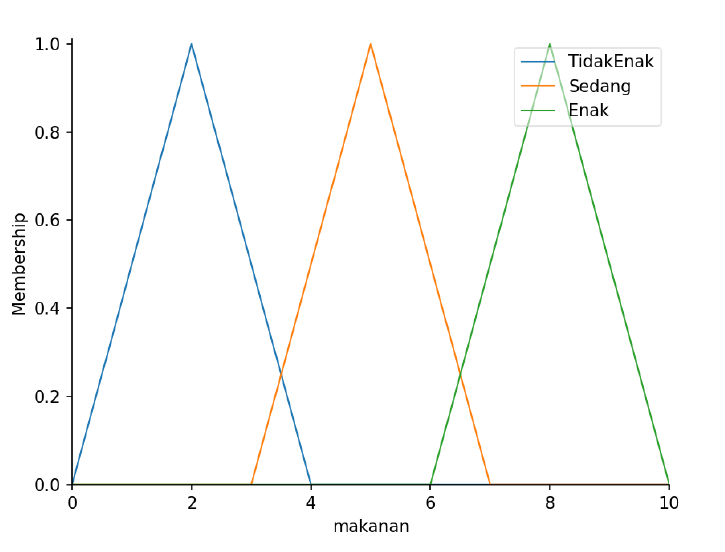

* Nilai Pelayanan
  * Definisi : Seberapa baik kualitas pelayanannya dalam skala 0-10?
  * Himpunan Fuzzy : Ketus, Biasa, Ramah
  * Fungsi Keanggotaan :

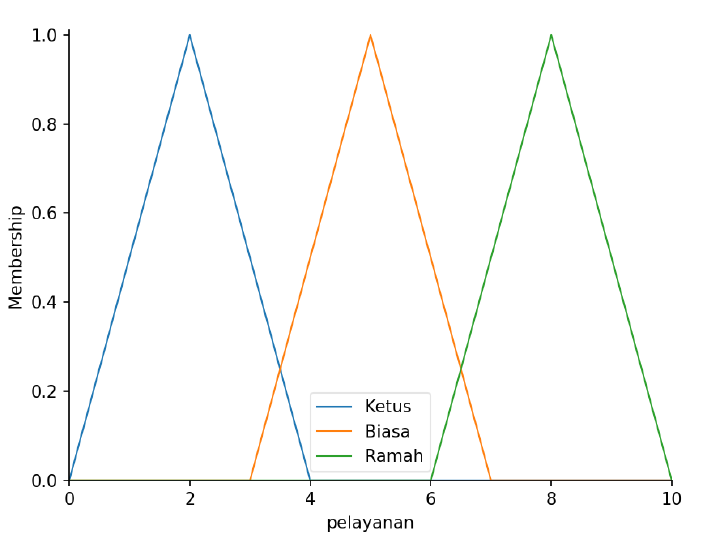

* Konsekuen (Output)
  * Nilai Restoran
    * Definisi : Seberapa baik nilai restoran dalam skala 0-10?
    * Himpunan Fuzzy : Buruk, Cukup, Baik
    * Fungsi Keanggotaan :

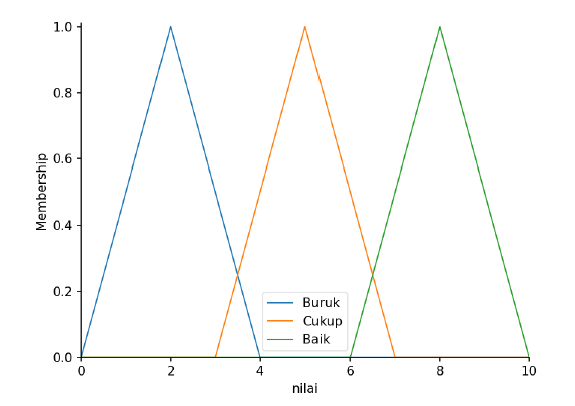

* Aturan
  * Jika makanan TIDAK ENAK dan pelayanan KETUS maka nilai total BURUK
  * Jika makanan SEDANG atau pelayanan BIASA maka nilai total CUKUP
  * Jika makanan ENAK atau pelayanan RAMAH maka nilai total BAIK

In [ ]:
# Import library
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
# Menyiapkan himpunan Fuzzy
makanan = ctrl.Antecedent(np.arange(0,11), 'makanan')
pelayanan = ctrl.Antecedent(np.arange(0,11), 'pelayanan')
nilai = ctrl.Consequent(np.arange(0,11), 'nilai')

# Rasa makanan
makanan['TidakEnak'] = fuzz.trimf(makanan.universe, [0, 2, 4])
makanan['Sedang'] = fuzz.trimf(makanan.universe, [3, 5, 7])
makanan['Enak'] = fuzz.trimf(makanan.universe, [6, 8, 10])

# Nilai pelayanan
pelayanan['Ketus'] = fuzz.trimf(pelayanan.universe, [0, 2, 4])
pelayanan['Biasa'] = fuzz.trimf(pelayanan.universe, [3, 5, 7])
pelayanan['Ramah'] = fuzz.trimf(pelayanan.universe, [6, 8, 10])

# Nilai restoran
nilai['Buruk'] = fuzz.trimf(nilai.universe, [0, 2, 4])
nilai['Cukup'] = fuzz.trimf(nilai.universe, [3, 5, 7])
nilai['Baik'] = fuzz.trimf(nilai.universe, [6, 8, 10])

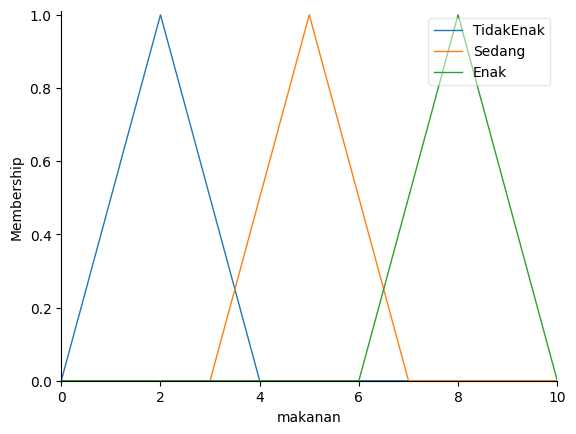

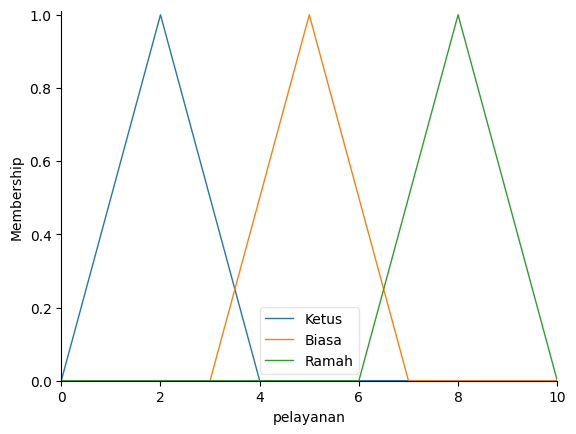

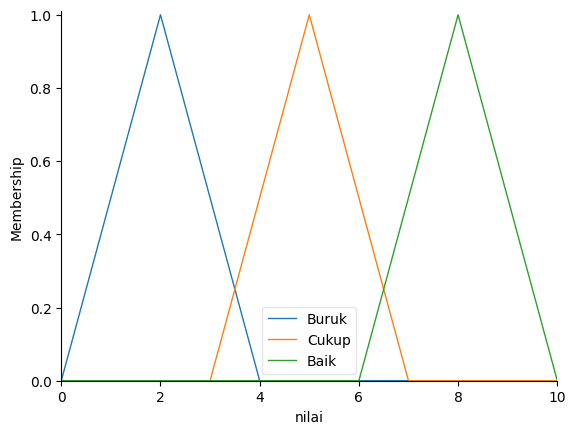

In [ ]:
makanan.view()
pelayanan.view()
nilai.view()

In [ ]:
aturan1 = ctrl.Rule(makanan['TidakEnak'] & pelayanan['Ketus'], nilai['Buruk'])
aturan2 = ctrl.Rule(makanan['Sedang'] | pelayanan['Biasa'], nilai['Cukup'])
aturan3 = ctrl.Rule(makanan['Enak'] | pelayanan['Ramah'], nilai['Baik'])

In [ ]:
engine = ctrl.ControlSystem([aturan1, aturan2, aturan3])
system = ctrl.ControlSystemSimulation(engine)

In [ ]:
system.input['makanan'] = 5.5
system.input['pelayanan'] = 7
system.compute()
print(system.output['nilai'])

6.333333333333333


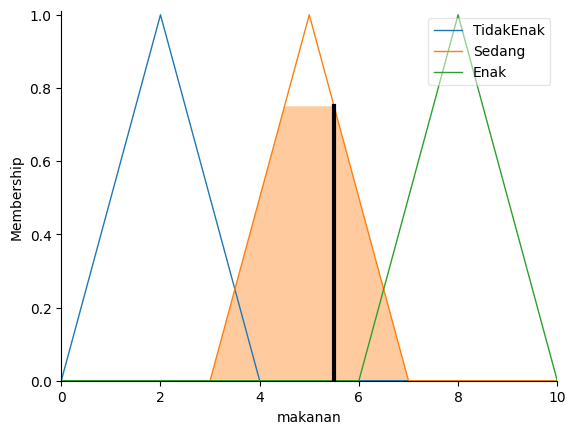

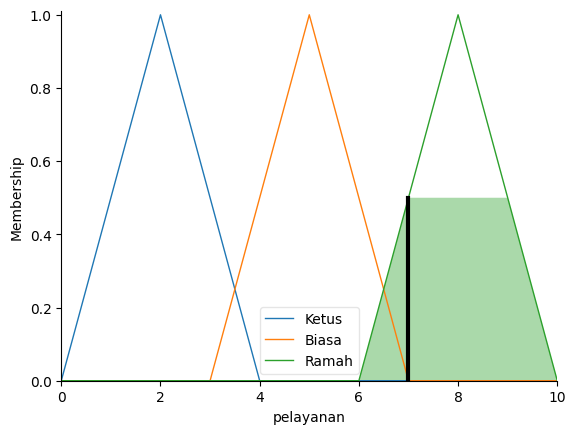

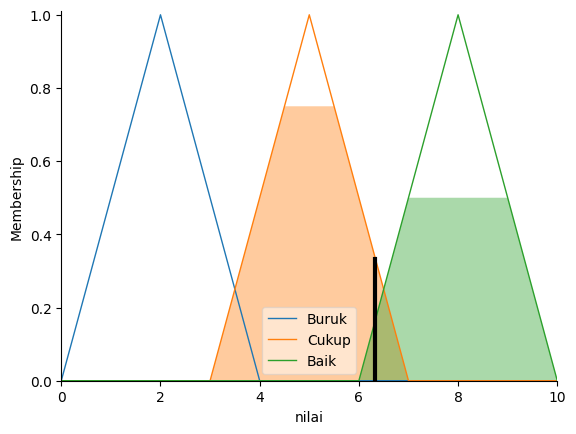

In [ ]:
makanan.view(sim=system)
pelayanan.view(sim=system)
nilai.view(sim=system)

---

## **Percobaan 2 - Perusahaan Soft Drink**


Diketahui sebagai berikut,
- Anteseden (Input)
    - Biaya Produksi
      - Definisi : Biaya yang dibutuhkan untuk memproduksi satu kemasan minuman, rata-rata Rp500 dan maksimum Rp1.000
      - Himpunan Fuzzy : Rendah, Standar, Tinggi
      - Fungsi Keanggotaan :

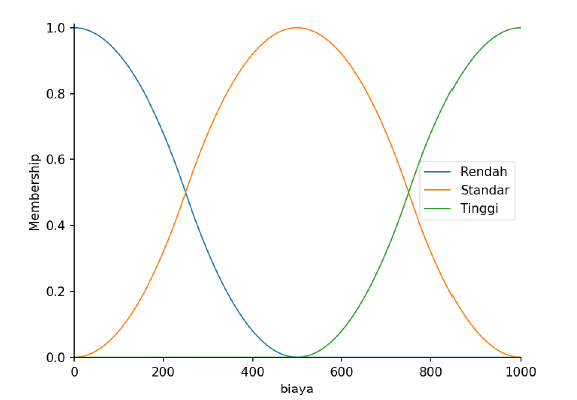

* Permintaan
  * Definisi : Banyaknya permintaan per harinya, rata-rata 30.000 kemasandan maksimum 60.000 kemasan
  * Himpunan Fuzzy : Turun, Biasa, Naik
  * Fungsi Keanggotaan :

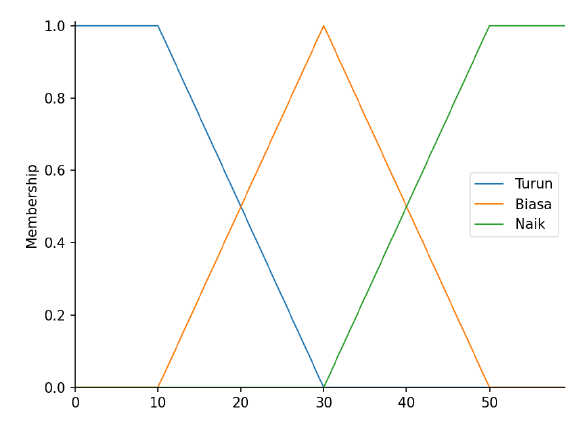

* Konsekuen (Output)
  * Produksi Barang
    * Definisi : Banyaknya minuman yang akan diproduksi perusahaan, maksimum 100.000 kemasan
    * Himpunan Fuzzy : Berkurang, Normal, Bertambah
    * Fungsi Keanggotaan :

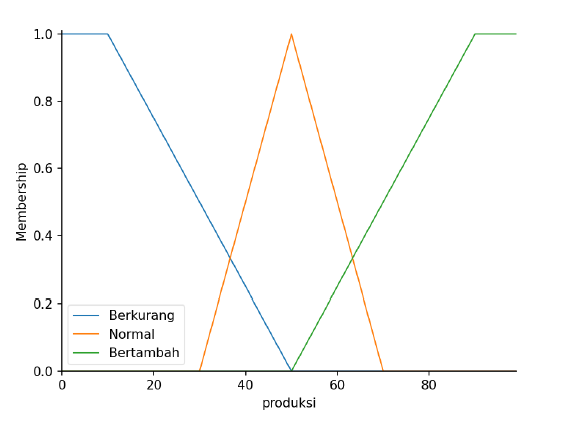

* Aturan
  * Jika biaya produksi RENDAH dan permintaan NAIK, maka produksi barang BERTAMBAH
  * Jika biaya produksi sesuai STANDAR, maka produksi barang NORMAL
  * Jika biaya produksi TINGGI dan permintaan TURUN, maka produksi barang BERKURANG

In [ ]:
# Import library
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
#Menyiapkan himpunan Fuzzy
biaya = ctrl.Antecedent(np.arange(0,1001), 'biaya')
permintaan = ctrl.Antecedent(np.arange(0,60), 'permintaan')
produksi = ctrl.Consequent(np.arange(0,100), 'produksi')

# Biaya produksi
biaya['Rendah'] = fuzz.zmf(biaya.universe, 0, 500)
biaya['Standar'] = fuzz.pimf(biaya.universe, 0, 500, 500, 1000)
biaya['Tinggi'] = fuzz.smf(biaya.universe, 500, 1000)

# Permintaan
permintaan['Turun'] = fuzz.trapmf(permintaan.universe, [0,0,10,30])
permintaan['Biasa'] = fuzz.trimf(permintaan.universe, [10,30,50])
permintaan['Naik'] = fuzz.trapmf(permintaan.universe, [30,50,60,60])

# Banyak produksi
produksi['Berkurang'] = fuzz.trapmf(produksi.universe, [0,0,10,50])
produksi['Normal'] = fuzz.trimf(produksi.universe, [30,50,70])
produksi['Bertambah'] = fuzz.trapmf(produksi.universe, [50,90,100,100])

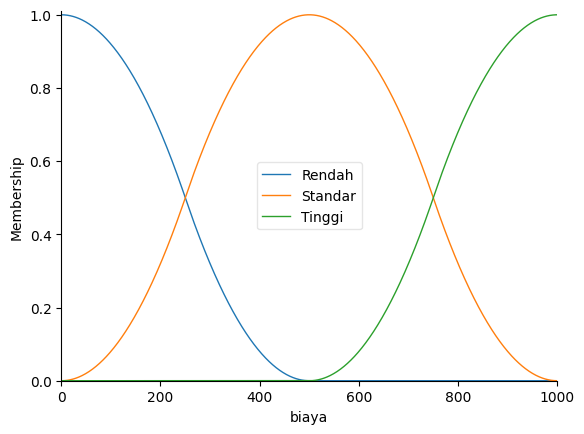

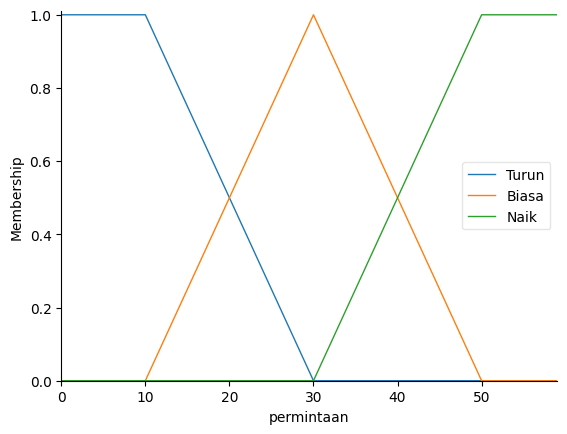

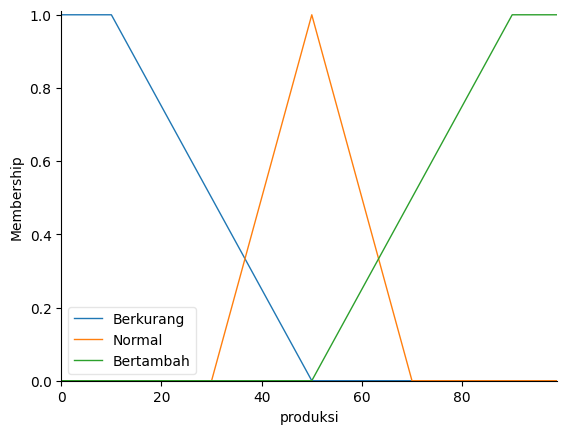

In [ ]:
biaya.view()
permintaan.view()
produksi.view()

In [ ]:
aturan1 = ctrl.Rule(biaya['Rendah'] & permintaan['Naik'], produksi['Bertambah'])
aturan2 = ctrl.Rule(biaya['Standar'], produksi['Normal'])
aturan3 = ctrl.Rule(biaya['Tinggi'] & permintaan['Turun'], produksi['Berkurang'])

In [ ]:
engine = ctrl.ControlSystem([aturan1, aturan2, aturan3])
system = ctrl.ControlSystemSimulation(engine)

In [ ]:
system.input['biaya'] = 500
system.input['permintaan'] = 30
system.compute()
print(system.output['produksi'])


49.99999999999999


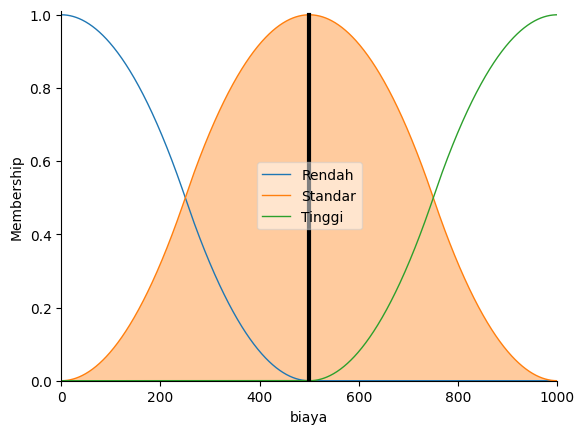

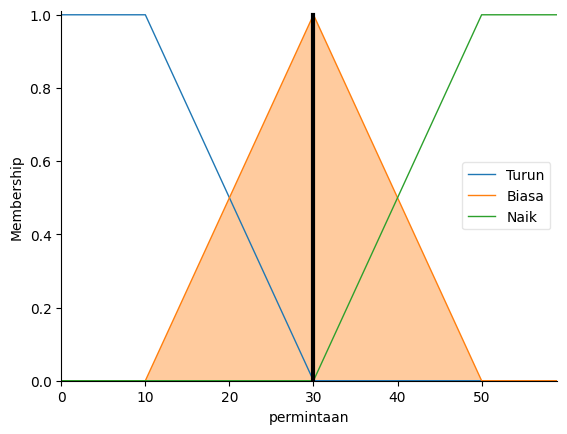

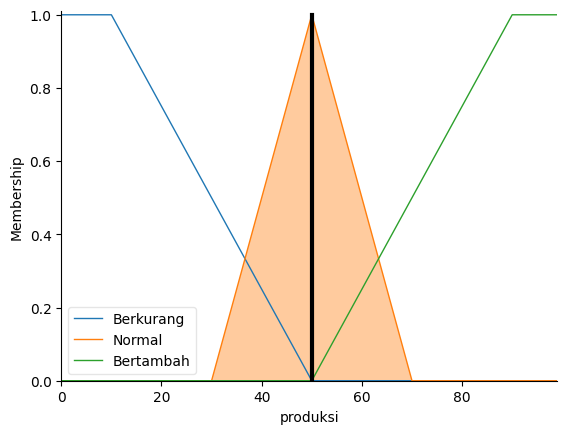

In [ ]:
biaya.view(sim=system)
permintaan.view(sim=system)
produksi.view(sim=system)

---
## **Tugas**

Pada source code library SciKit-Fuzzy, terdapat function compute() yang dipanggil untuk melakukan perhitungan output. Detail dari function tersebut dapat dilihat melalui link berikut

https://pythonhosted.org/scikit-fuzzy/_modules/skfuzzy/control/controlsystem.html#ControlSystemSimulation

1. Menurut source code tersebut, metode Fuzzy apa yang digunakan? Apakah
Mamdani/Sugeno/Tsukamoto?
2. Menurut source code tersebut, metode defuzzification apa yang digunakan? Bagaimana
cara mengubah metode defuzzification yang digunakan?
3. Jelaskan cara kerja function tersebut (compute) secara mendalam!

Upload ke GitHub dengan format: NIM-PraktikumKB-Materi2

**Jawaban :**

---

